# Clustering Energy Analysis

Thin runner notebook for LRK/xKV clustering comparisons across keys and values, with independent cells for each tensor and clustering axis.

In [1]:
import os
import sys
from pathlib import Path

import torch


def find_repo_root(start: Path) -> Path:
    for path in (start, *start.parents):
        if (path / "utils").is_dir():
            return path
    raise RuntimeError("Could not find repo root containing ./utils")


repo_root = find_repo_root(Path.cwd().resolve())
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from analysis.utils import display_case_result, load_kv_dump, run_analysis_case

%load_ext autoreload
%autoreload 2

/home/m84366023/miniconda3/envs/pem-llm/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
kv_dump_path = (
    repo_root
    / "results/kv_dumps/meta-llama_Llama-3.1-8B-Instruct/niah_multiquery_raw_kv.pt"
)
loaded = load_kv_dump(kv_dump_path)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

raw_keys = loaded["raw_keys"]
keys = loaded["keys"].to(device)
values = loaded["values"].to(device)
prompt_len = loaded["prompt_len"]
rope_theta = loaded["rope_theta"]

keys.shape, values.shape, prompt_len, rope_theta

Using device: cuda


(torch.Size([32, 1, 8, 3770, 128]),
 torch.Size([32, 1, 8, 3770, 128]),
 3770,
 500000.0)

In [13]:
show_detail_tables = False
plot_font_size = 14
show_bound_error_difference = False

if show_bound_error_difference:
    plot_figsize = (12, 6)
else:
    plot_figsize = (12, 4)

kmeans_cfg = {
    "n_clusters": 3,
    "kmeans_cluster_size": 512,
    "kmeans_n_iter": 16,
    "kmeans_init": "kmeans++",
    "kmeans_dtype": torch.float32,
}

decomposition_cfg = {
    "decomposition_method": "svd",
    "rank_selection": "comp_ratio",
    "comp_ratio": 4,
    "energy_threshold": 0.95,
    "decomp_n_iter": 3,
    "decomp_lr": 1e-2,
}

lrk_mode = "per_head"  # "avg_heads" or "per_head"
include_lrk_head_breakdown = False
prefix_end = prompt_len
local_window = 0

xkv_layer_group_size = 4
xkv_num_layers = keys.size(0)


def save_case_figures(figures, case_name):
    plot_names = ("lrk_heads", "lrk_layers", "xkv_groups")
    for figure, plot_name in zip(figures, plot_names, strict=True):
        if figure is None:
            continue
        save_path = f"plots/clustering_bounds_{case_name}_{plot_name}.svg"
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        figure.savefig(save_path, bbox_inches="tight", dpi=300)

## Keys, Row Clustering

In [4]:
keys_rows = run_analysis_case(
    keys,
    tensor_name="keys",
    cluster_axis="rows",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 128). Using rank 1.
  warnings.warn(


,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,keys_lrk_rows,256,0.232552,0.221707,0.226992,0.234495,0.034415,0.485646
1,keys_xkv_rows,40,0.237469,0.242633,0.156489,0.159749,0.113511,0.370066
2,keys_lrk_rows_n_clusters_1,256,0.315142,0.304667,0.251843,0.258953,0.074367,0.558442
3,keys_xkv_rows_n_clusters_1,40,0.311980,0.306936,0.121584,0.123666,0.173713,0.473684


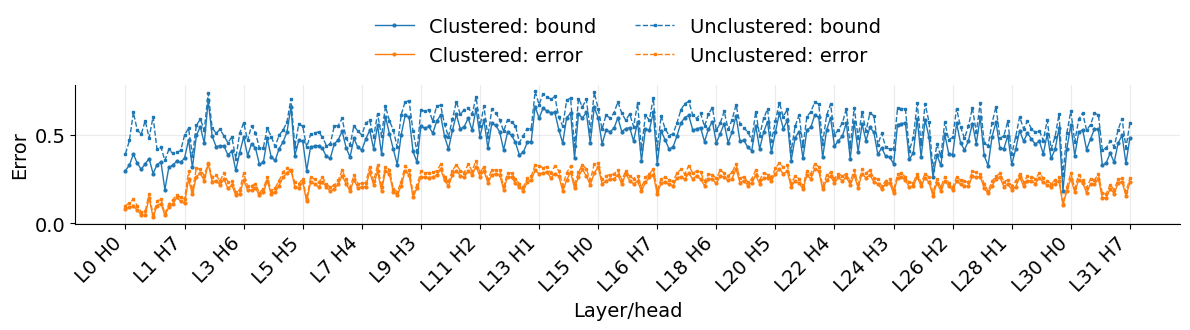

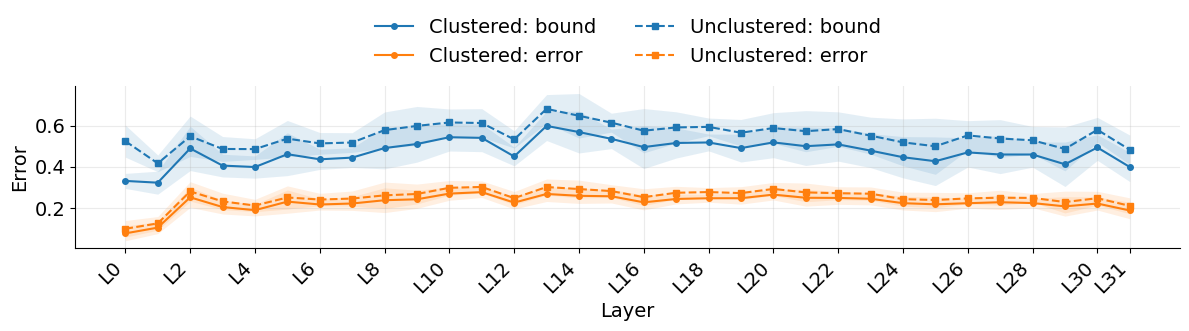

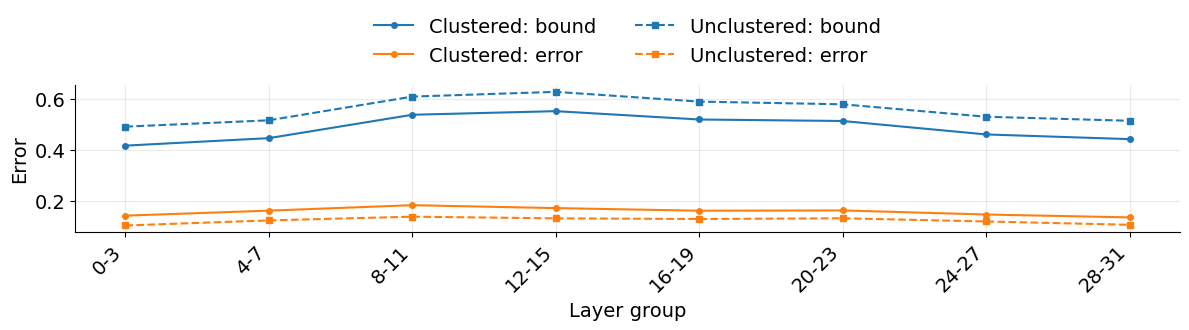

In [14]:

keys_row_figures = display_case_result(
    keys_rows,
    show_detail_tables=show_detail_tables,
    plot_font_size=plot_font_size,
    plot_figsize=plot_figsize,
    show_bound_error_difference=show_bound_error_difference,
)
save_case_figures(keys_row_figures, keys_rows["case_name"])

## Values, Row Clustering

In [6]:
values_rows = run_analysis_case(
    values,
    tensor_name="values",
    cluster_axis="rows",
    kmeans_cfg=kmeans_cfg,
    decomposition_cfg=decomposition_cfg,
    lrk_mode=lrk_mode,
    include_lrk_head_breakdown=include_lrk_head_breakdown,
    prefix_end=prefix_end,
    local_window=local_window,
    xkv_layer_group_size=xkv_layer_group_size,
    xkv_num_layers=xkv_num_layers,
)

/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (2, 128). Using rank 1.
  warnings.warn(
/mnt/jfs-00/team-agent/home/m84366023/gist_vs_details/utils/matrix_decomposition.py:39: UserWarning: Target compression ratio 4 is too high for matrix of shape (1, 128). Using rank 1.
  warnings.warn(


,case,rows,mean_eta,median_eta,mean_relative_low_rank_recon_error,median_relative_low_rank_recon_error,min_eta,max_eta
0,values_lrk_rows,256,0.785803,0.812311,0.567463,0.572723,0.142219,0.948980
1,values_xkv_rows,40,0.812425,0.832393,0.426723,0.431695,0.479592,0.888889
2,values_lrk_rows_n_clusters_1,256,0.891137,0.922806,0.631394,0.642685,0.213010,0.988571
3,values_xkv_rows_n_clusters_1,40,0.883943,0.905339,0.358285,0.353400,0.528061,0.944751


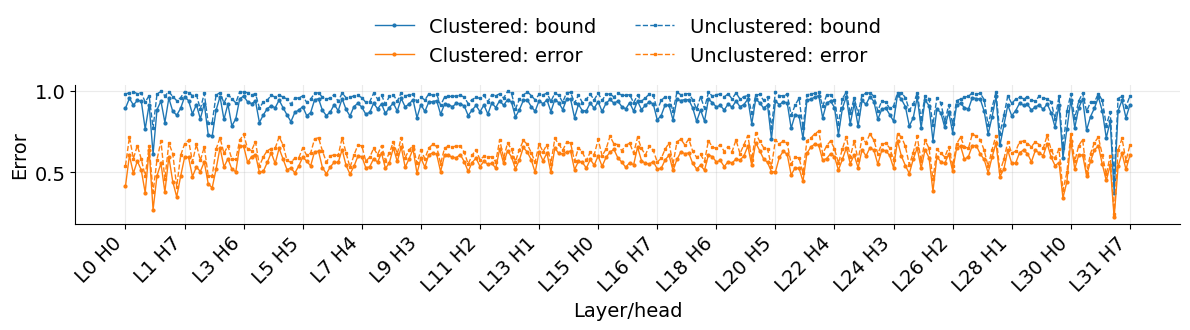

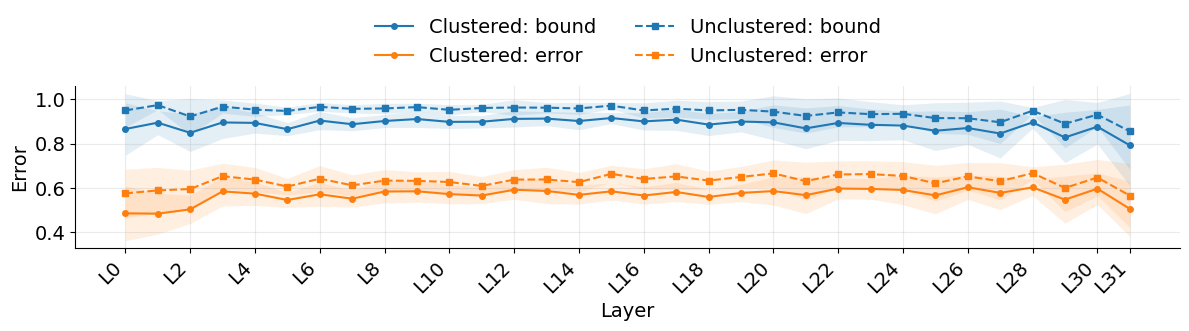

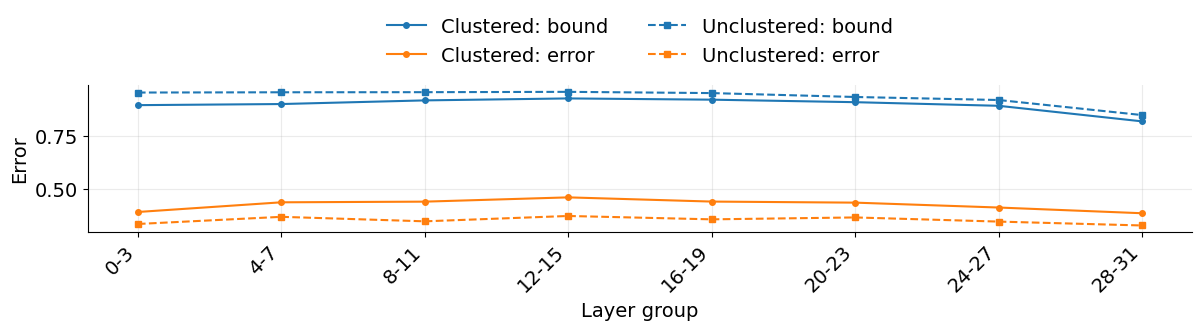

In [15]:
values_row_figures = display_case_result(
    values_rows,
    show_detail_tables=show_detail_tables,
    plot_font_size=plot_font_size,
    plot_figsize=plot_figsize,
    show_bound_error_difference=show_bound_error_difference,
)
save_case_figures(values_row_figures, values_rows["case_name"])